In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('wine_data.csv',header= None, usecols=[0,1,2])
df.columns = ['Class Label', 'Alcohol', 'Malic Acid']

In [8]:
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [9]:
# Lets see the distribution of the data.

<Axes: xlabel='Alcohol', ylabel='Density'>

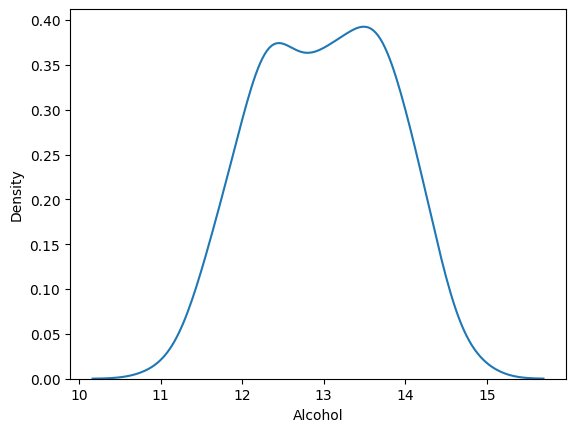

In [10]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

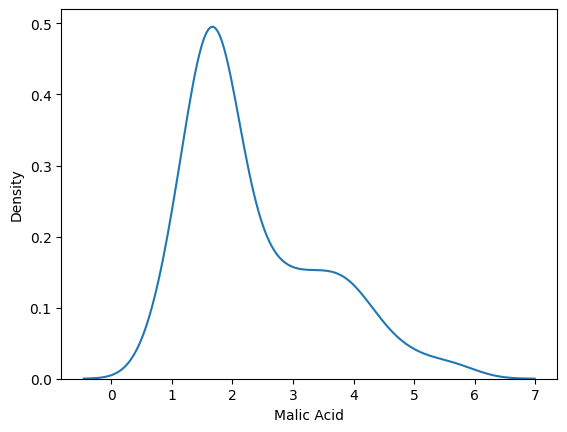

In [11]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

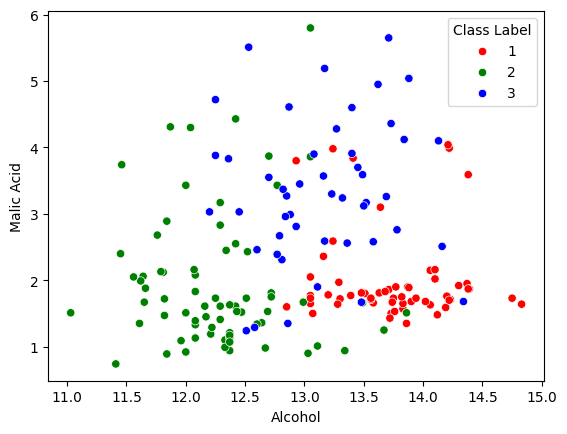

In [22]:
color_dict = {1:'red',2:'green',3:'blue'}
sns.scatterplot(x = df['Alcohol'],y = df['Malic Acid'], data = df, hue = df['Class Label'],palette= color_dict)

In [23]:
# Now ,for any type of transformation , first need to train_test_split the data.

In [28]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,1:]
y = df['Class Label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3 , random_state=0)

In [34]:
X_train

,Alcohol,Malic Acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [29]:
X_train.shape , X_test.shape

((124, 2), (54, 2))

In [30]:
# Now Normalizations are different types :-
# min max normalization
# Mean normalization
# MaxAbsScaling
# Robust Scaling

In [31]:
# MinMax Normalization

# Xi' = (Xi - Xmin)/(Xmax - Xmin)
# Outcome Range -> 0-1

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the paramter.
# fit on the only X_train data
scaler.fit(X_train)

# transform train and test sets.
# now Transform the data on both X_train and X_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
X_train_scaled  # After transforming, data becomes series.

array([[0.72043011, 0.20378151],
       [0.31989247, 0.08403361],
       [0.60215054, 0.71218487],
       [0.57258065, 0.56302521],
       [0.76075269, 0.1302521 ],
       [0.48924731, 0.5       ],
       [0.75537634, 0.67857143],
       [0.61021505, 0.17436975],
       [0.54301075, 0.62394958],
       [0.39784946, 0.07352941],
       [0.33870968, 0.1092437 ],
       [0.46774194, 0.53361345],
       [0.5188172 , 0.53781513],
       [0.70967742, 0.07563025],
       [0.57258065, 0.30882353],
       [0.36021505, 0.0105042 ],
       [0.38709677, 0.13235294],
       [0.20967742, 0.25840336],
       [0.59408602, 0.64915966],
       [0.82526882, 0.26680672],
       [0.15591398, 0.09663866],
       [0.52688172, 0.16386555],
       [0.46774194, 0.31512605],
       [0.65860215, 0.16386555],
       [0.1155914 , 0.5987395 ],
       [0.27956989, 0.26680672],
       [0.21236559, 0.12184874],
       [0.65053763, 0.59033613],
       [0.31451613, 0.44957983],
       [0.54301075, 0.17647059],
       [0.

In [36]:
# so converted back to dataframe

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [37]:
X_train_scaled

,Alcohol,Malic Acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [38]:
X_test_scaled

,Alcohol,Malic Acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513
5,0.142473,0.243697
6,0.814516,0.264706
7,0.357527,0.617647
8,0.327957,0.176471
9,0.282258,0.197479


In [44]:
np.round(X_train.describe(),1)  # This is original data

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [43]:
np.round(X_train_scaled.describe(),1)  # this is after MinMax normalization -> min = 0,  max = 1

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [45]:
# check after transforming ,is any changes in the data.

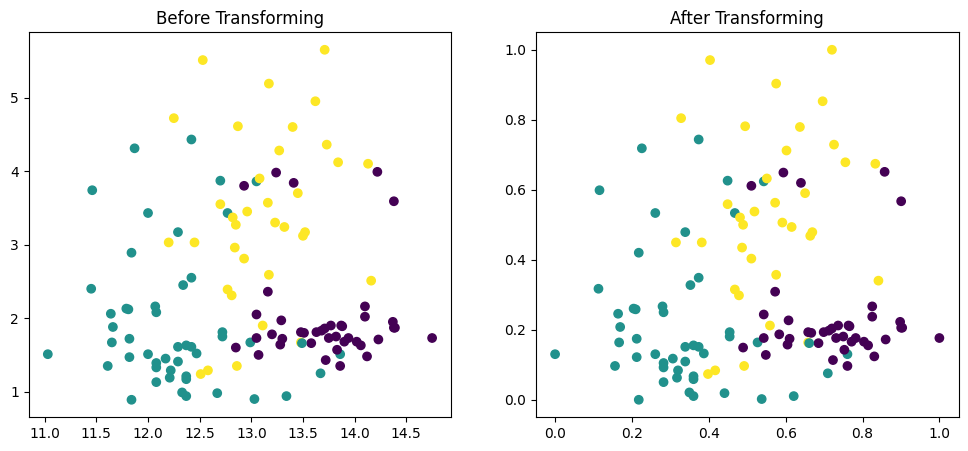

In [48]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))

ax1.set_title('Before Transforming')
ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'],c=y_train)

ax2.set_title('After Transforming')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic Acid'],c = y_train)

plt.show()

In [50]:
# so only the scale in change , the destribution remains same.
# scaled between ->  0-1

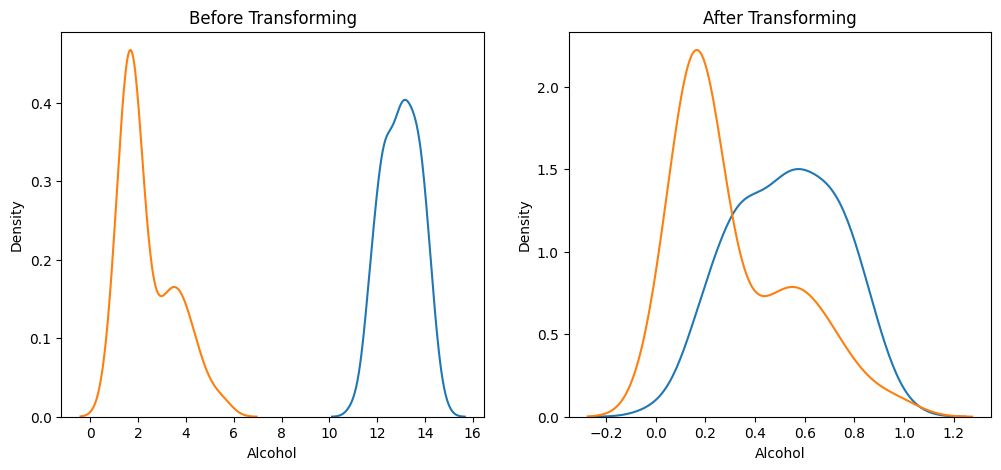

In [52]:
fig, (ax1, ax2) = plt.subplots(nrows = 1,ncols = 2, figsize=(12,5))

ax1.set_title('Before Transforming')
sns.kdeplot(X_train['Alcohol'],ax = ax1)
sns.kdeplot(X_train['Malic Acid'], ax= ax1)

ax2.set_title('After Transforming')
sns.kdeplot(X_train_scaled['Alcohol'],ax = ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax = ax2)

plt.show()

In [53]:
# we can see that before both in different ranges, after both comes in range (0,1)

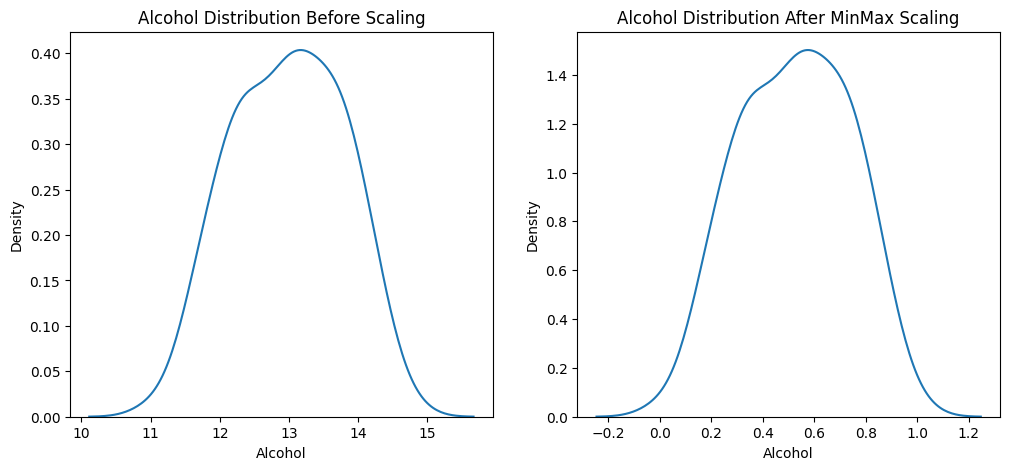

In [56]:
# comparing Before and After of Alcohol

fig, (ax1, ax2) = plt.subplots(ncols=2,nrows=1, figsize=(12, 5))

# before transforming
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after transforming
ax2.set_title('Alcohol Distribution After MinMax Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

plt.show()

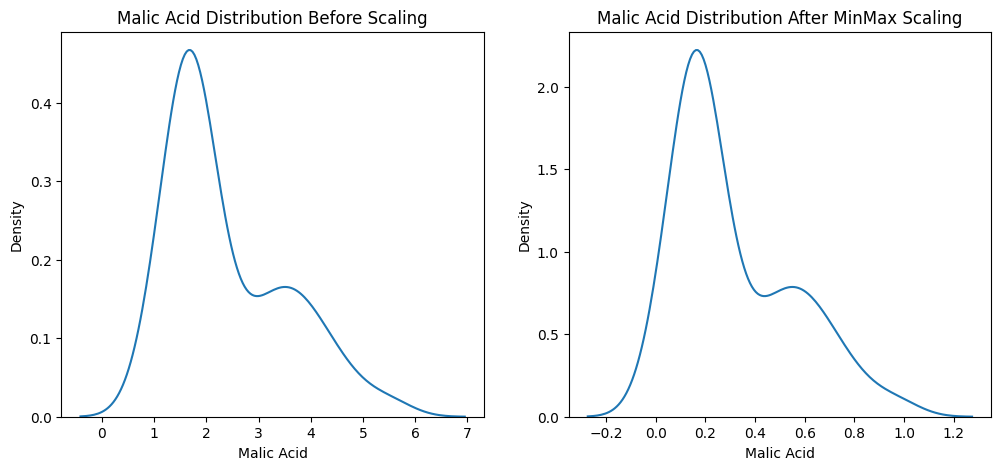

In [57]:
# comparing Before and After of Malic Acid

fig, (ax1, ax2) = plt.subplots(ncols=2,nrows=1, figsize=(12, 5))

# before transforming
ax1.set_title('Malic Acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after transforming
ax2.set_title('Malic Acid Distribution After MinMax Scaling')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)

plt.show()

In [58]:
# Mean Normalization

# Xi' = (Xi - Xmean)/(Xmax - Xmin)
# Outcome Range -> -1 - 1
# use for centering data.


In [60]:
# MaxAbsScaling

# it is use when our data has sparse data (many zeros.)

# Xi' = Xi / |Xmax|

In [61]:
# Robust Scaling

# Xi' = (Xi - Xmedium)/(IQR)

# it is use when data has outliers

In [62]:
# Normalization Vs Standardization

# when the min and max value is given then use normalization, otherwise standardization.